# **Module One Problem Set: Multiple Regression**

## **Step 1: Loading the Data Set**

You are an analyst working for a car maker. You have access to a set of data that can be used to study the fuel economy of a car. Car makers are interested in studying factors that are associated with better fuel economy. This data set includes several important variables that are associated with fuel economy. You will use this data set to create models to predict fuel economy.

| <div style="text-align: left"> Variable </div>  |   <div style="text-align: left"> What does it represent? </div> |
| -- | --  |
| <div style="text-align: left"> mpg </div> | <div style="text-align: left"> Fuel economy in miles/(US) gallon </div> |
| <div style="text-align: left"> cyl </div> | <div style="text-align: left"> Number of cylinders in car's engine. Values are (4, 6, 8) </div> |
| <div style="text-align: left"> disp </div> | <div style="text-align: left"> Displacement (cu.in.) measures overall volume in the engine as a factor of cylinder circumfrance, depth and total number of cylinders. This metric is a good proxy for the total amount of power the engine can generate.</div> |
| <div style="text-align: left"> hp </div> | <div style="text-align: left"> Gross horsepower measures the theoretical output of an engine’s power output.</div> |
| <div style="text-align: left"> drat </div> | <div style="text-align: left"> Rear axle ratio indicates the number of turns of the drive shaft for every one rotation of the wheel axle. A vehicle with a high ratio would provide more torque. </div> |
| <div style="text-align: left"> wt </div> | <div style="text-align: left"> Weight of the car per 1,000 lbs. </div>|
| <div style="text-align: left"> qsec </div> | <div style="text-align: left"> Quarter mile time is a performance measure of acceleration of the car.</div>|
| <div style="text-align: left"> vs </div> | <div style="text-align: left"> Engine's cylinder configuration as V-shaped or straight. Configuration offers trade offs in power/torque, design usage in terms of space/size of engine and performance or center of gravity of vehicle. Values are (0 = V-shaped, 1 = straight) </div> |
| <div style="text-align: left"> am </div> | <div style="text-align: left"> Automatic or Manual transmission. Values are (0 = automatic, 1 = manual) </div> |
| <div style="text-align: left"> gear </div> | <div style="text-align: left"> Number of gears in the transmission.</div> |

This block of R code will load the data set from **mtcars.csv** file.

In [17]:
# Loading mtcars data set from a mtcars.csv file
mtcars <- read.csv(file='mtcars.csv', header=TRUE, sep=",")

# Converting appropriate variables to factors  
mtcars2 <- within(mtcars, {
   vs <- factor(vs)
   am <- factor(am)
   cyl  <- factor(cyl)
   gear <- factor(gear)
   carb <- factor(carb)
})

# Variables and their type
print("Variables")
sapply(mtcars2, class)


# Print the data set
print("dataset")
mtcars2


# Print the first 10 rows
print("head")
head(mtcars2, 10)

[1] "Variables"


car       mpg       cyl      disp        hp      drat        wt      qsec 
 "factor" "numeric"  "factor" "numeric" "integer" "numeric" "numeric" "numeric" 
       vs        am      gear      carb 
 "factor"  "factor"  "factor"  "factor"

[1] "dataset"


car,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


[1] "head"


car,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


## **Step 2: Basic Information on the Data Set**

In this step, you will use some R functions to obtain basic information on the data set. This includes obtaining the column (variable) names, the total number of variables, and the total number of rows.

In [18]:
# This prints the column names
print("names")
names(mtcars2)

# Another function that prints the column names
print("colnames")
colnames(mtcars2)

# Total number of columns in the data set
print("ncol")
ncol(mtcars2)

# Total number of rows in the data set
print("nrow")
nrow(mtcars2)

[1] "names"


[1] "car"  "mpg"  "cyl"  "disp" "hp"   "drat" "wt"   "qsec" "vs"   "am"  
[11] "gear" "carb"

[1] "colnames"


[1] "car"  "mpg"  "cyl"  "disp" "hp"   "drat" "wt"   "qsec" "vs"   "am"  
[11] "gear" "carb"

[1] "ncol"


[1] 12

[1] "nrow"


[1] 32

## **Step 3: Histogram**

In this step, you will use the hist function in R to print the histogram for the variable mpg in the data set.

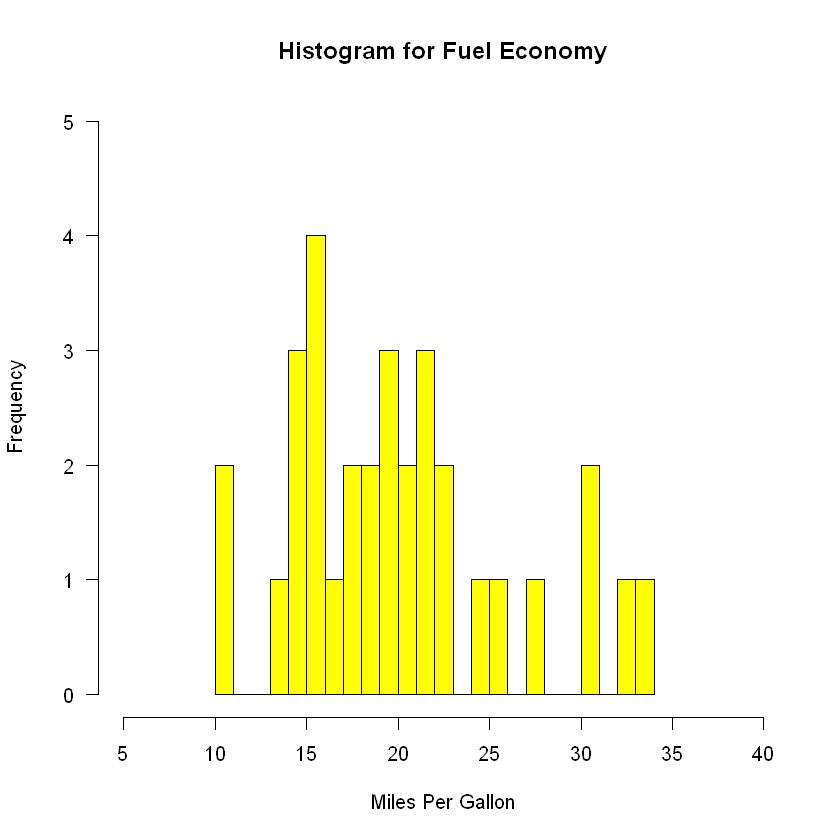

In [19]:
hist(mtcars2$mpg, 
     main="Histogram for Fuel Economy", 
     xlab="Miles Per Gallon", 
     border="black", 
     col="yellow",
     xlim=c(5,40),
     ylim=c(0,5),
     las=1, 
     breaks=20)

## **Step 4: Scatterplot**

1. Create a scatterplot of fuel efficiency (mpg) against rear axle ratio (drat) and include a copy in this report. 
2. Create a scatterplot of fuel efficiency (mpg) against horsepower (hp) and include a copy in this report. 
3. Calculate Pearson Correlation Coefficients between fuel efficiency and rear axle ratio and between fuel efficiency and horsepower.

[1] "min drat"
[1] 2.76
[1] "max drat"
[1] 4.93
[1] "min hp"
[1] 52
[1] "max hp"
[1] 335


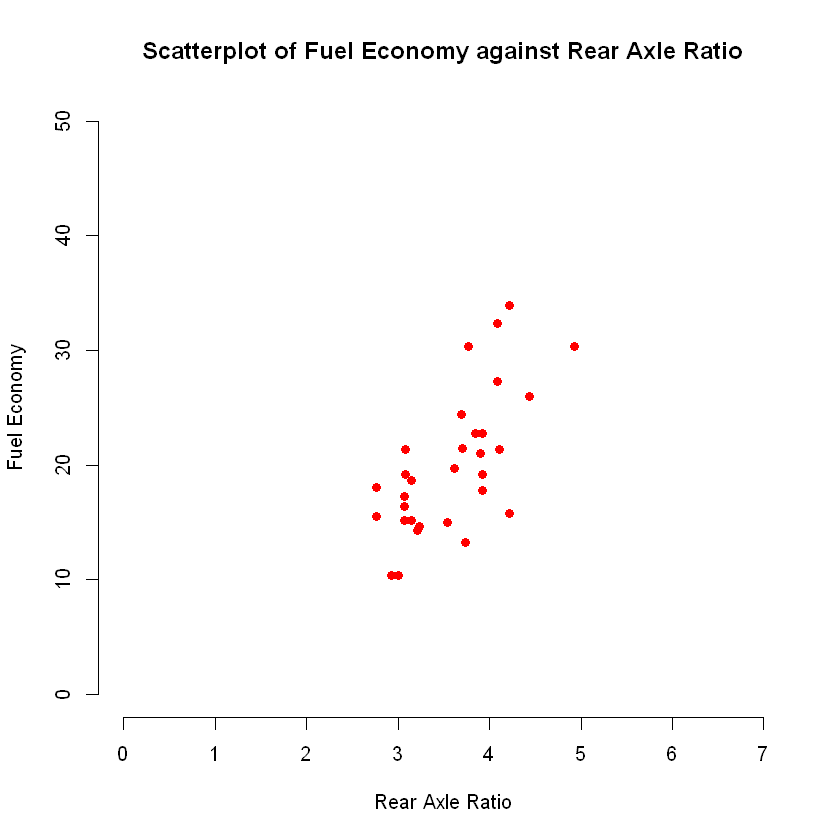

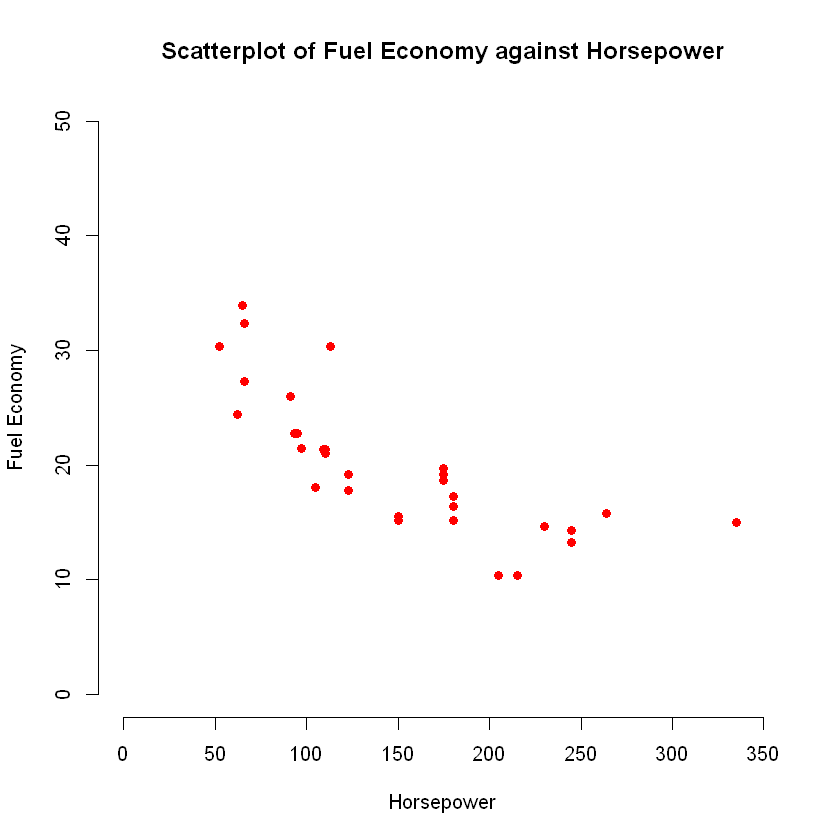

In [20]:
# find the mix and max of drat for plot x and y limits
min_drat <- min(mtcars2$drat)
print("min drat")
print(min_drat)

max_drat <- max(mtcars2$drat)
print("max drat")
print(max_drat)

# find the mix and max of hp for plot for x and y limits
min_drat <- min(mtcars2$hp)
print("min hp")
print(min_drat)

max_drat <- max(mtcars2$hp)
print("max hp")
print(max_drat)


# create scatterplot for mpg against drat
plot(mtcars2$drat, mtcars$mpg, 
     main = "Scatterplot of Fuel Economy against Rear Axle Ratio",
     xlab = "Rear Axle Ratio", ylab = "Fuel Economy",
     xlim=c(0, 7),
     ylim=c(0, 50),
     col="red", 
     pch = 19, frame = FALSE)

# create a scatterplot for mpg against hp
plot(mtcars2$hp, mtcars$mpg, 
     main = "Scatterplot of Fuel Economy against Horsepower",
     xlab = "Horsepower", ylab = "Fuel Economy",
     xlim=c(0, 350),
     ylim=c(0, 50),
     col="red", 
     pch = 19, frame = FALSE)



## **Step 5: Subsetting Data and Correlation Matrix**

In this step, you will create a subset of the original data set to select some variables. Then, you will print the correlation matrix for the selected variables

In [21]:
# Selecting mpg, drat, and hp variables to subset the data
myvars <- c("mpg","drat","hp")
mtcars_subset <- mtcars2[myvars]

# Print the first 10 rows
print("head")
head(mtcars_subset, 10)

# Print the correlation matrix
print("cor")
corr_matrix <- cor(mtcars_subset, method = "pearson")
round(corr_matrix, 4)

[1] "head"


mpg,drat,hp
21.0,3.90,110
21.0,3.90,110
22.8,3.85,93
21.4,3.08,110
18.7,3.15,175
18.1,2.76,105
14.3,3.21,245
24.4,3.69,62
22.8,3.92,95
19.2,3.92,123


[1] "cor"


,mpg,drat,hp
mpg,1.0000,0.6812,-0.7762
drat,0.6812,1.0000,-0.4488
hp,-0.7762,-0.4488,1.0000


## **Step 6: Multiple Regression**

In this step, you will create a multiple regression model for fuel economy as the response variable, and rear axle ratio and horsepower as predictor variables. You will print summary statistics of this model that will help evaluate the significance and utility of the model.

In [22]:
# Create the multiple regression model and print the statistics
model <- lm(mpg ~ drat + hp, data=mtcars_subset)
summary(model)


Call:
lm(formula = mpg ~ drat + hp, data = mtcars_subset)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.0369 -2.3487 -0.6034  1.1897  7.7500 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 10.789861   5.077752   2.125 0.042238 *  
drat         4.698158   1.191633   3.943 0.000467 ***
hp          -0.051787   0.009293  -5.573 5.17e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 3.17 on 29 degrees of freedom
Multiple R-squared:  0.7412,	Adjusted R-squared:  0.7233 
F-statistic: 41.52 on 2 and 29 DF,  p-value: 3.081e-09


## **Step 7: Fitted Values**

In this step, you will obtain the fitted values of the data set. Recall that the fitted value is just the predicted value of the dependent variable (miles per gallon) for data points from the data set.

In [23]:
fitted_values <- fitted.values(model) 
fitted_values

1        2        3        4        5        6        7        8 
23.41614 23.41614 24.06161 19.56366 16.52639 18.31918 13.18322 24.91529 
       9       10       11       12       13       14       15       16 
24.28691 22.83688 22.83688 15.89161 15.89161 15.89161 13.93920 13.75020 
      17       18       19       20       21       22       23       24 
14.05398 26.54043 31.25887 27.24995 23.14974 15.98878 17.82106 15.62626 
      25       26       27       28       29       30       31       32 
16.19752 26.54043 26.89011 22.65002 16.94441 18.73453 10.07281 24.45454

## **Step 8: Residuals**

In this step, you will obtain the residuals. Recall that the residual is the difference between the actual value and the predicted value of the dependent variable (miles per gallon).

In [24]:
residuals <- residuals(model)
residuals

1          2          3          4          5          6          7 
-2.4161450 -2.4161450 -1.2616101  1.8363444  2.1736056 -0.2191784  1.1167817 
         8          9         10         11         12         13         14 
-0.5152911 -1.4869079 -3.6368817 -5.0368817  0.5083915  1.4083915 -0.6916085 
        15         16         17         18         19         20         21 
-3.5392002 -3.3502047  0.6460187  5.8595740 -0.8588732  6.6500453 -1.6497399 
        22         23         24         25         26         27         28 
-0.4887791 -2.6210606 -2.3262604  3.0024767  0.7595740 -0.8901149  7.7499755 
        29         30         31         32 
-1.1444113  0.9654715  4.9271881 -3.0545448

## **Step 9: Diagnostic Plots — Residuals against Fitted Values**

In this step, you will generate a plot of residuals against fitted values to test the assumption of homoscadasticity.

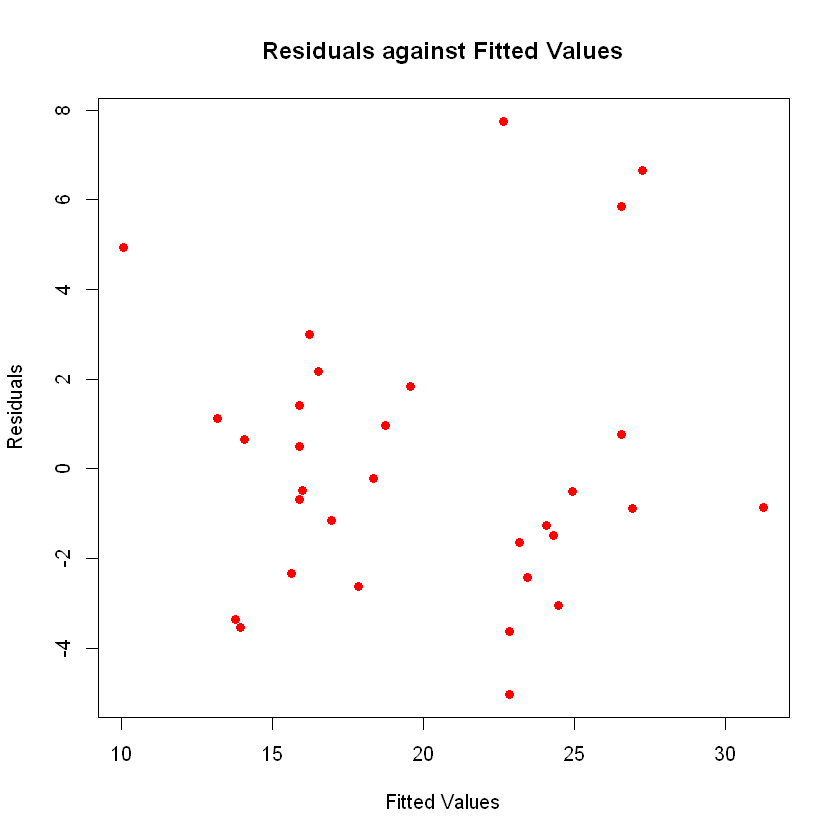

In [25]:
# creating scatter plot
plot(fitted_values, residuals, 
     main = "Residuals against Fitted Values",
     xlab = "Fitted Values", ylab = "Residuals",
     col="red", 
     pch = 19)

## **Step 10: Diagnostic Plots — Q-Q Plot**

In this step, you will generate a Q-Q plot to test assumptions of normality of the residuals.

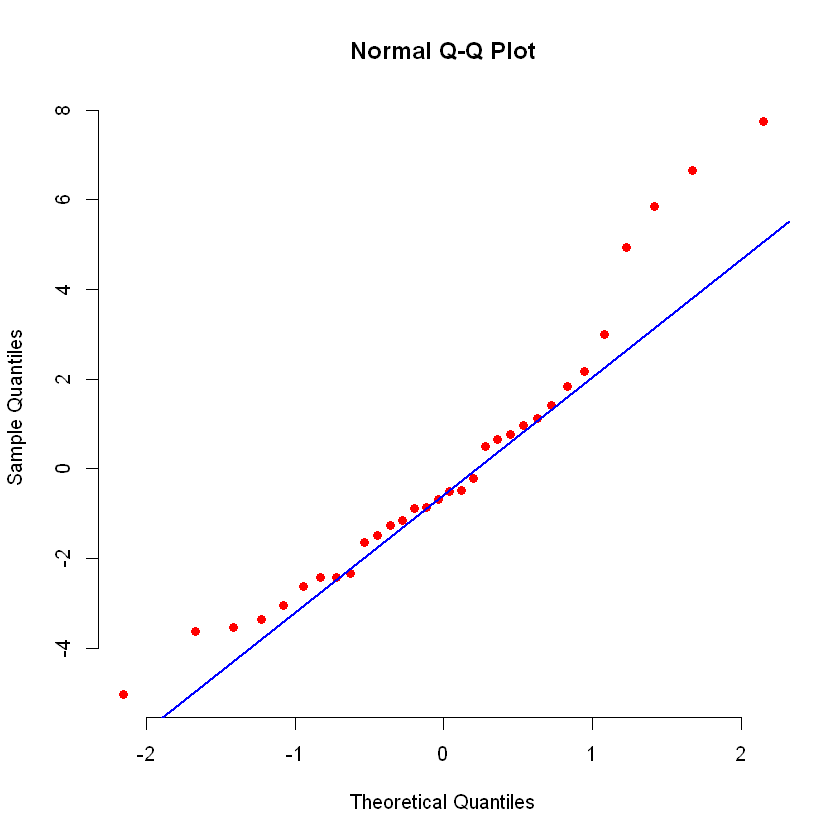

In [26]:
# creating Q-Q plot
qqnorm(residuals, pch = 19, col="red", frame = FALSE)
qqline(residuals, col = "blue", lwd = 2)



## **Step 11: Confidence Intervals for Parameter Estimates**

n this step, you will use the confint function to create 90% confidence intervals for the beta parameter estimates

In [27]:
# confidence intervals for model parameters
print("confint")
conf_90_int <- confint(model, level=0.90) 
round(conf_90_int, 4)

# 95% confidence interval
print("confint")
conf_90_int <- confint(model, level=0.95) 
round(conf_90_int, 4)


[1] "confint"


,5 %,95 %
(Intercept),2.1621,19.4176
drat,2.6734,6.7229
hp,-0.0676,-0.0360


[1] "confint"


,2.5 %,97.5 %
(Intercept),0.4047,21.1750
drat,2.2610,7.1353
hp,-0.0708,-0.0328


## **Step 12: Predictions, Prediction Interval, and Confidence Interval**

In this step, you will predict the fuel economy for a car that has a drat of 3.15 and hp of 120. You will also obtain a 90% prediction interval and confidence interval for this prediction. Note that this observation is not from the data set that was used to create this model.

In [28]:
newdata <- data.frame(drat=3.15, hp=120)

print("prediction interval")
prediction_pred_int <- predict(model, newdata, interval="predict", level=0.95) 
round(prediction_pred_int, 4)

print("confidence interval")
prediction_conf_int <- predict(model, newdata, interval="confidence", level=0.95) 
round(prediction_conf_int, 4)

[1] "prediction interval"


fit,lwr,upr
19.3747,12.6449,26.1045


[1] "confidence interval"


fit,lwr,upr
19.3747,17.5716,21.1777


**Along with this file will be a analysis report attached, where I make sense of my findings and what I have concluded based on the information I found on mpg, rear axle ration, and horsepower**